In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("../data/processed/primary")

OUTPATIENT = BASE / "outpatient_ml_ready.csv"
INPATIENT = BASE / "inpatient_ml_ready.csv"
CARRIER = BASE / "carrier_ml_ready.csv"

print("EDA visualization pipeline ready.")

EDA visualization pipeline ready.


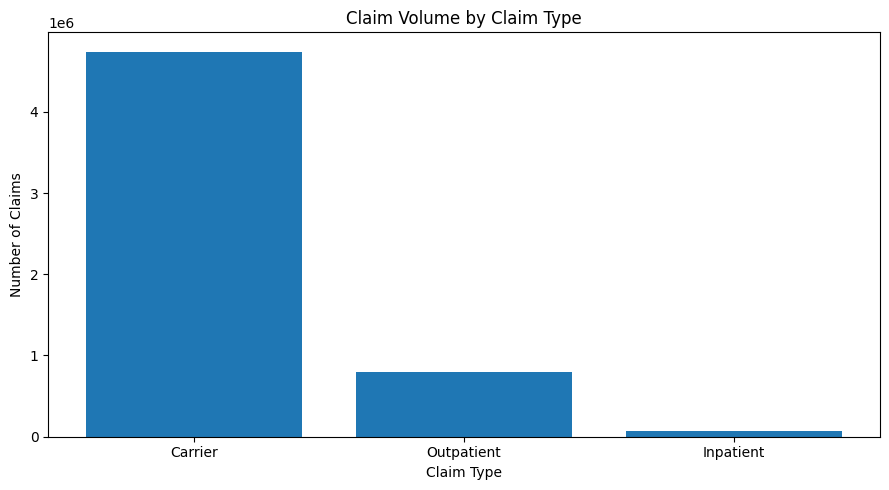

In [2]:
# ============================================================
# CLAIM TYPE VOLUME
# ============================================================

claim_counts = {
    "Carrier": 4_741_335,
    "Outpatient": 790_790,
    "Inpatient": 66_773
}

plt.figure(figsize=(9, 5))

plt.bar(
    claim_counts.keys(),
    claim_counts.values()
)

plt.title("Claim Volume by Claim Type")
plt.xlabel("Claim Type")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

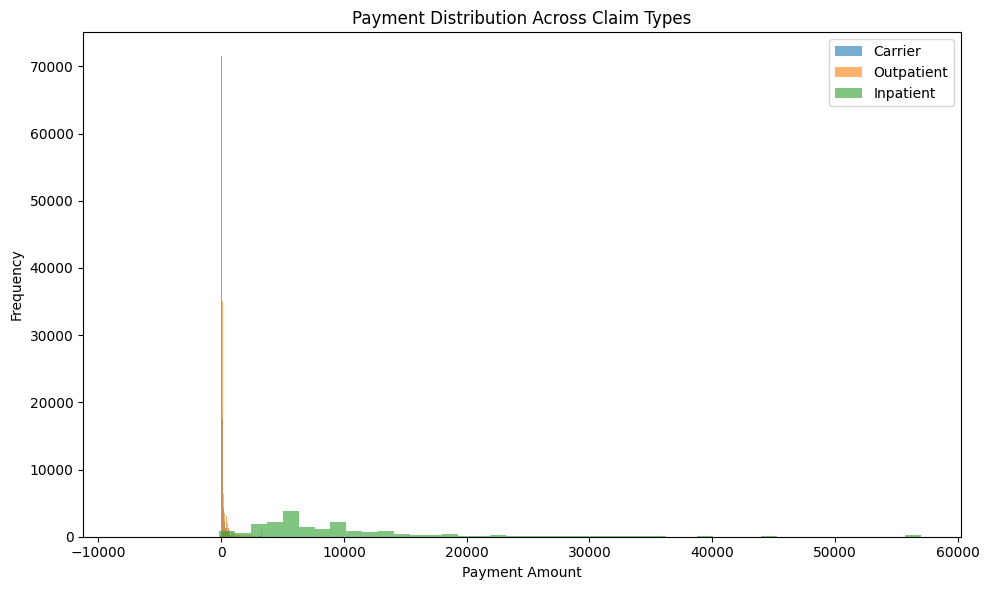

In [3]:
# ============================================================
# PAYMENT DISTRIBUTIONS
# ============================================================

def sample_column(
    file,
    column,
    sample_size=100_000,
    chunksize=250_000
):
    samples = []

    for chunk in pd.read_csv(
        file,
        usecols=[column],
        chunksize=chunksize
    ):
        values = chunk[column].dropna()

        if len(values) > 0:
            take = min(
                len(values),
                max(1, int(sample_size / 5))
            )

            samples.append(
                values.sample(
                    n=take,
                    random_state=42
                )
            )

    result = pd.concat(samples)

    if len(result) > sample_size:
        result = result.sample(
            sample_size,
            random_state=42
        )

    return result


carrier_payment = sample_column(
    CARRIER,
    "total_claim_payment_amt"
)

outpatient_payment = sample_column(
    OUTPATIENT,
    "CLM_PMT_AMT"
)

inpatient_payment = sample_column(
    INPATIENT,
    "CLM_PMT_AMT"
)

plt.figure(figsize=(10, 6))

plt.hist(
    carrier_payment,
    bins=50,
    alpha=0.6,
    label="Carrier"
)

plt.hist(
    outpatient_payment,
    bins=50,
    alpha=0.6,
    label="Outpatient"
)

plt.hist(
    inpatient_payment,
    bins=50,
    alpha=0.6,
    label="Inpatient"
)

plt.title("Payment Distribution Across Claim Types")
plt.xlabel("Payment Amount")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

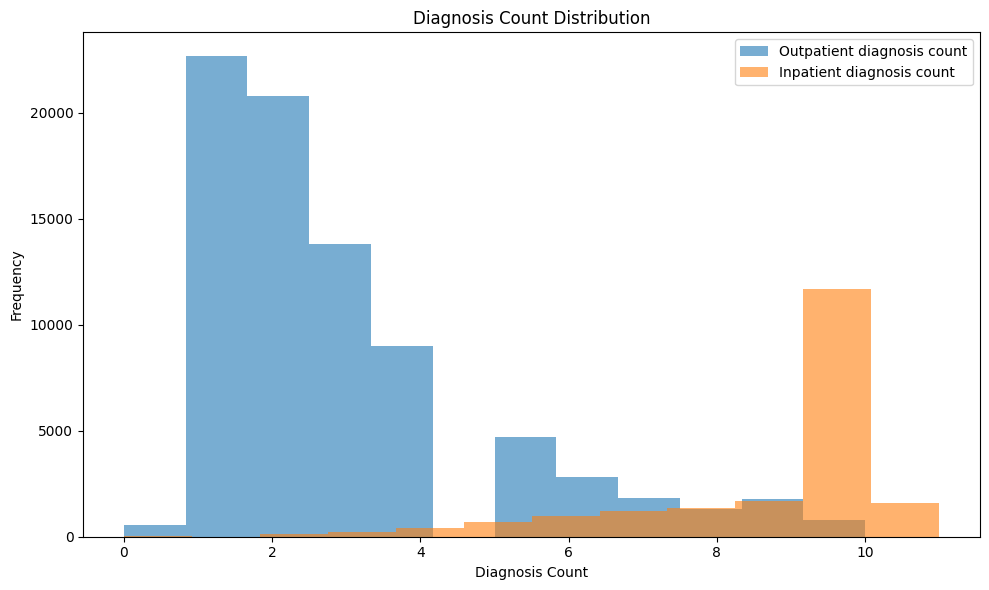

In [4]:
# ============================================================
# UTILIZATION FEATURES
# ============================================================

out_diag = sample_column(
    OUTPATIENT,
    "DIAGNOSIS_COUNT"
)

out_proc = sample_column(
    OUTPATIENT,
    "PROCEDURE_COUNT"
)

out_hcpcs = sample_column(
    OUTPATIENT,
    "HCPCS_COUNT"
)

inp_diag = sample_column(
    INPATIENT,
    "DIAGNOSIS_COUNT"
)

inp_proc = sample_column(
    INPATIENT,
    "PROCEDURE_COUNT"
)

plt.figure(figsize=(10, 6))

plt.hist(
    out_diag,
    bins=12,
    alpha=0.6,
    label="Outpatient diagnosis count"
)

plt.hist(
    inp_diag,
    bins=12,
    alpha=0.6,
    label="Inpatient diagnosis count"
)

plt.title("Diagnosis Count Distribution")
plt.xlabel("Diagnosis Count")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

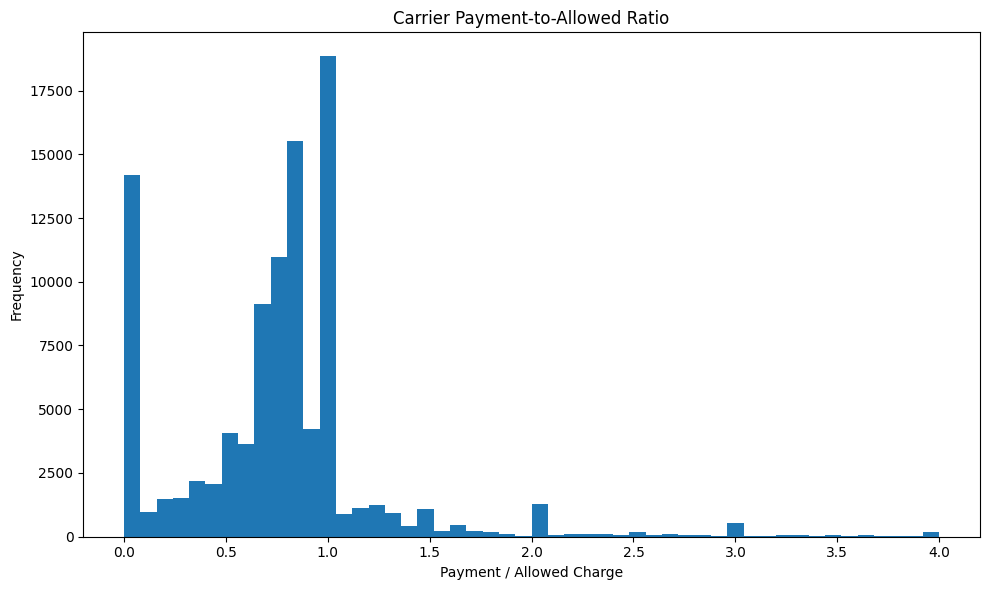

In [5]:
# ============================================================
# CARRIER PAYMENT-TO-ALLOWED RATIO
# ============================================================

ratio = sample_column(
    CARRIER,
    "payment_to_allowed_ratio"
)

# Remove extreme values for visualization only
ratio_plot = ratio[
    ratio.between(
        ratio.quantile(0.01),
        ratio.quantile(0.99)
    )
]

plt.figure(figsize=(10, 6))

plt.hist(
    ratio_plot,
    bins=50
)

plt.title("Carrier Payment-to-Allowed Ratio")
plt.xlabel("Payment / Allowed Charge")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

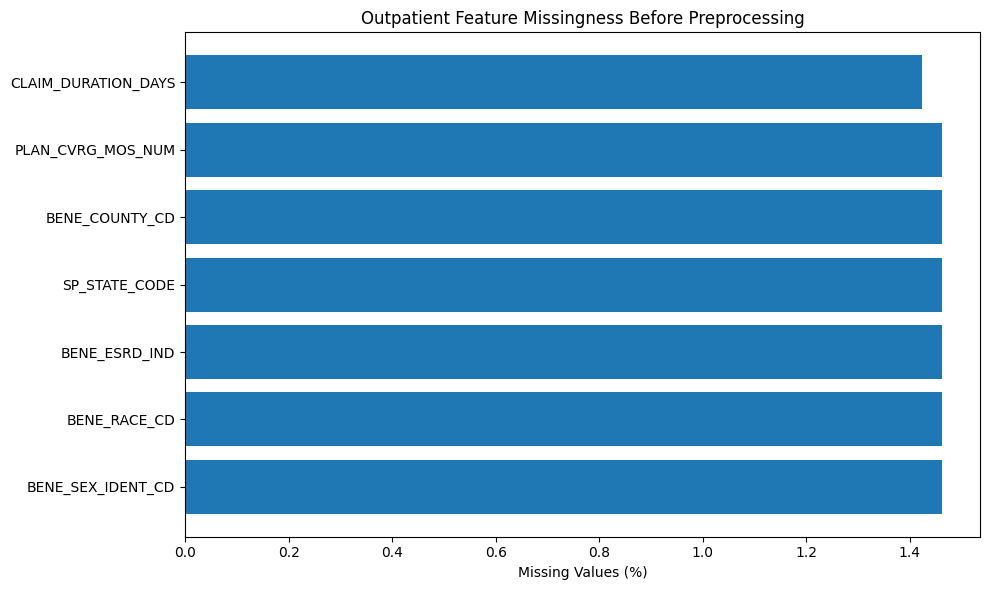

In [6]:
# ============================================================
# MISSINGNESS ANALYSIS
# ============================================================

def missing_summary(file, columns):

    totals = {}
    rows = 0

    for chunk in pd.read_csv(
        file,
        usecols=columns,
        chunksize=250_000
    ):

        rows += len(chunk)

        for col in columns:
            if col not in totals:
                totals[col] = 0

            totals[col] += chunk[col].isna().sum()

    result = pd.Series(totals)

    return (
        result / rows * 100
    ).sort_values(ascending=False)


out_missing = missing_summary(
    OUTPATIENT,
    [
        "BENE_SEX_IDENT_CD",
        "BENE_RACE_CD",
        "BENE_ESRD_IND",
        "SP_STATE_CODE",
        "BENE_COUNTY_CD",
        "PLAN_CVRG_MOS_NUM",
        "CLAIM_DURATION_DAYS"
    ]
)

plt.figure(figsize=(10, 6))

plt.barh(
    out_missing.index,
    out_missing.values
)

plt.title("Outpatient Feature Missingness Before Preprocessing")
plt.xlabel("Missing Values (%)")

plt.tight_layout()
plt.show()

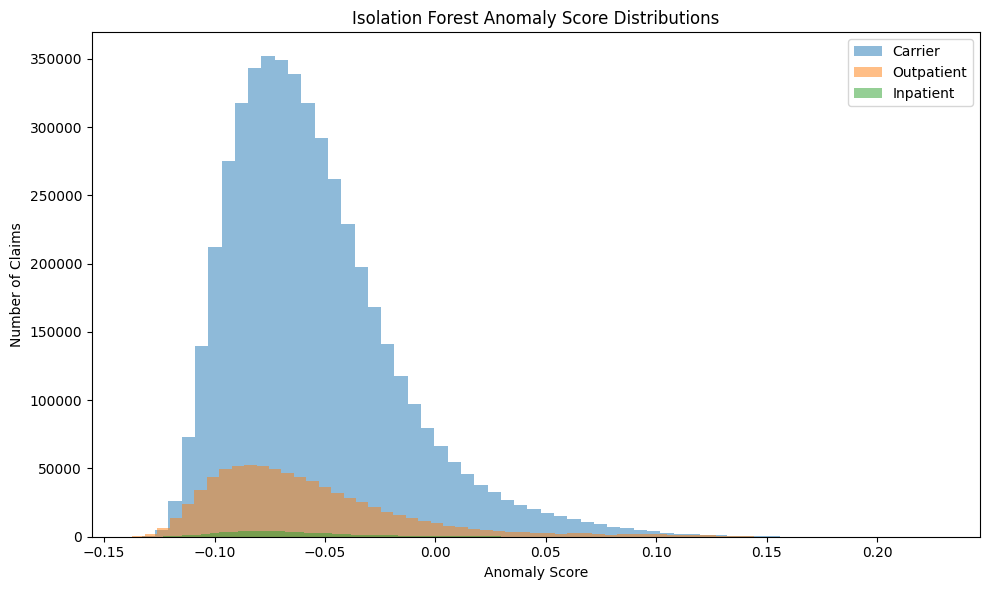

In [7]:
# ============================================================
# ANOMALY SCORE DISTRIBUTIONS
# ============================================================

def load_scores(file):

    values = []

    for chunk in pd.read_csv(
        file,
        usecols=["ANOMALY_SCORE"],
        chunksize=250_000
    ):
        values.append(chunk["ANOMALY_SCORE"])

    return pd.concat(values, ignore_index=True)


carrier_scores = load_scores(
    BASE / "carrier_anomaly_scores.csv"
)

outpatient_scores = load_scores(
    BASE / "outpatient_anomaly_scores.csv"
)

inpatient_scores = load_scores(
    BASE / "inpatient_anomaly_scores.csv"
)

plt.figure(figsize=(10, 6))

plt.hist(
    carrier_scores,
    bins=60,
    alpha=0.5,
    label="Carrier"
)

plt.hist(
    outpatient_scores,
    bins=60,
    alpha=0.5,
    label="Outpatient"
)

plt.hist(
    inpatient_scores,
    bins=60,
    alpha=0.5,
    label="Inpatient"
)

plt.title("Isolation Forest Anomaly Score Distributions")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Claims")
plt.legend()

plt.tight_layout()
plt.show()